First 5 rows:
         Date     Product  Quantity  Price Customer_ID Region  Total_Sales
0  2024-01-01       Phone         7  37300     CUST001   East       261100
1  2024-01-02  Headphones         4  15406     CUST002  North        61624
2  2024-01-03       Phone         2  21746     CUST003   West        43492
3  2024-01-04  Headphones         1  30895     CUST004   East        30895
4  2024-01-05      Laptop         8  39835     CUST005  North       318680

--- Descriptive Statistics ---
Mean:
 Quantity            4.78
Price           25808.51
Total_Sales    123650.48
dtype: float64

Median:
 Quantity           5.0
Price          24192.0
Total_Sales    97955.5
dtype: float64

Mode:
 Quantity          4.0
Price          1308.0
Total_Sales    6540.0
Name: 0, dtype: float64

Standard Deviation:
 Quantity            2.588163
Price           13917.630242
Total_Sales    100161.085275
dtype: float64

--- Distribution Analysis ---


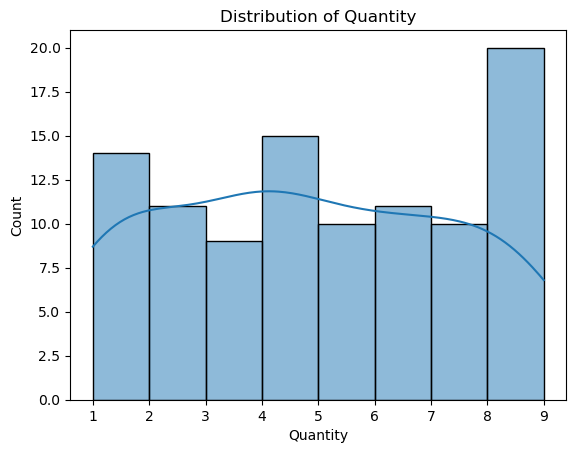

Quantity → Shapiro p-value: 0.0001
  Not Normally Distributed


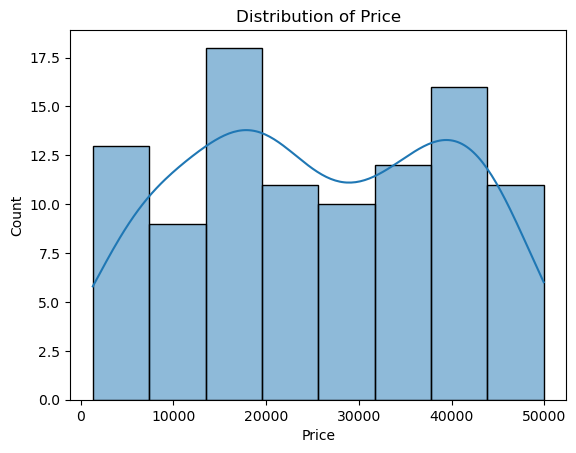

Price → Shapiro p-value: 0.0006
  Not Normally Distributed


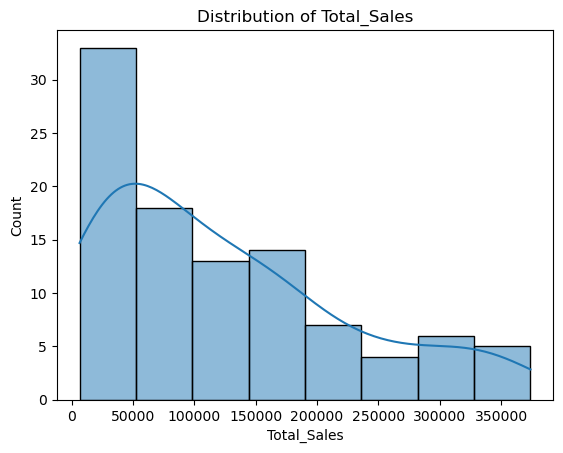

Total_Sales → Shapiro p-value: 0.0000
  Not Normally Distributed

--- Correlation Analysis ---
             Quantity     Price  Total_Sales
Quantity     1.000000  0.008014     0.688107
Price        0.008014  1.000000     0.646131
Total_Sales  0.688107  0.646131     1.000000


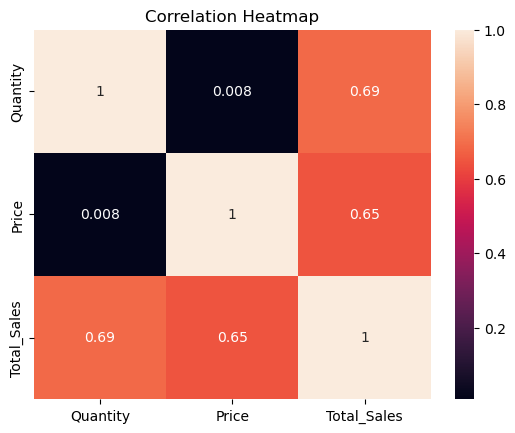


--- Hypothesis Testing ---

--- Confidence Interval (95%) ---

--- Regression Analysis ---

--- Business Insights ---

Analysis Complete ✅


In [2]:
# ==============================
# 📦 Import Libraries
# ==============================
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from scipy.stats import shapiro, ttest_1samp, ttest_ind, f_oneway, t
from sklearn.linear_model import LinearRegression

# ==============================
# 📂 Load Dataset
# ==============================
df = pd.read_csv("sales_data.csv")

print("First 5 rows:")
print(df.head())

# ==============================
# 📊 1. Descriptive Statistics
# ==============================
print("\n--- Descriptive Statistics ---")
print("Mean:\n", df.mean(numeric_only=True))
print("\nMedian:\n", df.median(numeric_only=True))
print("\nMode:\n", df.mode(numeric_only=True).iloc[0])
print("\nStandard Deviation:\n", df.std(numeric_only=True))

# ==============================
# 📊 2. Distribution Analysis
# ==============================
print("\n--- Distribution Analysis ---")

numeric_cols = df.select_dtypes(include=np.number).columns

for col in numeric_cols:
    plt.figure()
    sns.histplot(df[col], kde=True)
    plt.title(f"Distribution of {col}")
    plt.show()

    stat, p = shapiro(df[col])
    print(f"{col} → Shapiro p-value: {p:.4f}")
    if p > 0.05:
        print("  Looks Normally Distributed")
    else:
        print("  Not Normally Distributed")

# ==============================
# 🔗 3. Correlation Analysis
# ==============================
print("\n--- Correlation Analysis ---")

corr = df.corr(numeric_only=True)
print(corr)

plt.figure()
sns.heatmap(corr, annot=True)
plt.title("Correlation Heatmap")
plt.show()

# ==============================
# 🧪 4. Hypothesis Testing
# ==============================
print("\n--- Hypothesis Testing ---")

# Ensure 'Sales' exists
if 'Sales' in df.columns:

    # ✅ One-sample t-test
    t_stat, p_val = ttest_1samp(df['Sales'], popmean=df['Sales'].mean())
    print(f"\nOne-sample T-test p-value: {p_val:.4f}")

    # ✅ Independent T-test (if Region exists)
    if 'Region' in df.columns:
        regions = df['Region'].dropna().unique()
        if len(regions) >= 2:
            group1 = df[df['Region'] == regions[0]]['Sales']
            group2 = df[df['Region'] == regions[1]]['Sales']

            t_stat, p_val = ttest_ind(group1, group2)
            print(f"Independent T-test ({regions[0]} vs {regions[1]}) p-value: {p_val:.4f}")

    # ✅ ANOVA (if Region exists)
    if 'Region' in df.columns:
        groups = [group['Sales'] for name, group in df.groupby('Region')]
        if len(groups) > 1:
            f_stat, p_val = f_oneway(*groups)
            print(f"ANOVA p-value: {p_val:.4f}")

# ==============================
# 📐 5. Confidence Interval
# ==============================
print("\n--- Confidence Interval (95%) ---")

if 'Sales' in df.columns:
    mean = np.mean(df['Sales'])
    std = np.std(df['Sales'], ddof=1)
    n = len(df)

    confidence = 0.95
    t_crit = t.ppf((1 + confidence) / 2, df=n-1)

    margin_error = t_crit * (std / np.sqrt(n))

    lower = mean - margin_error
    upper = mean + margin_error

    print(f"Mean Sales: {mean:.2f}")
    print(f"95% CI: ({lower:.2f}, {upper:.2f})")

# ==============================
# 📈 6. Regression Analysis
# ==============================
print("\n--- Regression Analysis ---")

if 'Marketing_Spend' in df.columns and 'Sales' in df.columns:
    X = df[['Marketing_Spend']]
    y = df['Sales']

    model = LinearRegression()
    model.fit(X, y)

    r2 = model.score(X, y)

    print(f"R-squared: {r2:.4f}")
    print(f"Slope: {model.coef_[0]:.4f}")
    print(f"Intercept: {model.intercept_:.2f}")

    # Plot regression
    plt.figure()
    plt.scatter(X, y)
    plt.plot(X, model.predict(X))
    plt.title("Marketing Spend vs Sales")
    plt.xlabel("Marketing Spend")
    plt.ylabel("Sales")
    plt.show()

# ==============================
# 💡 7. Business Insights
# ==============================
print("\n--- Business Insights ---")

if 'Marketing_Spend' in df.columns and 'Sales' in df.columns:
    corr_value = df['Marketing_Spend'].corr(df['Sales'])
    print(f"Correlation between Marketing Spend and Sales: {corr_value:.2f}")

    if corr_value > 0.7:
        print("Strong positive relationship → Marketing is highly effective")
    elif corr_value > 0.3:
        print("Moderate relationship → Marketing has some impact")
    else:
        print("Weak relationship → Marketing impact is low")

print("\nAnalysis Complete ✅")